# 3D With hubble sphere = 0.30
Best fit curve when we define a maximum range where planets can occupy other planets. I believe I = 0.30 here

In [ ]:
###### from math import log
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

data1 = np.loadtxt("3D_with_enclosure_static,curve,k=vary,sims=1,hb=5.0.dat")
k1 = data1[:, 0]
t1 = data1[:, 1]
# D_o = data1[0, 1]
beta = 32.24

# print(t1)
# print(k1)




R^2 score: 0.9992


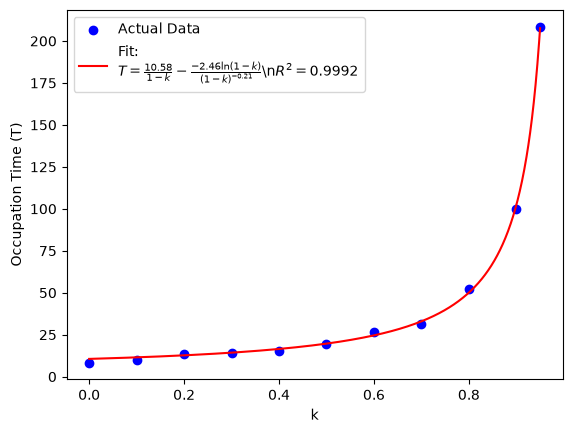

In [4]:

# 1. Define the 3-parameter Logistic Growth Model
def occupation_time(k,D,beta, gamma):
    return D / (1 - k) - beta * np.log(1 - k) / ((1 - k) ** gamma)


# Fit curve
p0 = [10,33, 1.0]
popt, _ = curve_fit(occupation_time, k1, t1, p0=p0)
D_fit, beta_fit, gamma_fit = popt


# --- Calculate Coefficient of Determination (R^2) ---
t1_pred = occupation_time(k1, *popt)
ss_res = np.sum((t1 - t1_pred) ** 2)  # Residual sum of squares
ss_tot = np.sum((t1 - np.mean(t1)) ** 2)  # Total sum of squares
r2 = 1 - (ss_res / ss_tot)  # R^2 score
6
print(f"R^2 score: {r2:.4f}")

# Label including R^2
eq_label = (
    rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}} - "
    rf"\frac{{{float(beta_fit):.2f} \ln(1 - k)}}{{(1 - k)^{{{gamma_fit:.2f}}}}}$"
    rf"\n$R^2 = {r2:.4f}$"
)

k_dense = np.linspace(min(k1), max(k1), 1000)
t_fit = occupation_time(k_dense, *popt)

# Plot
plt.scatter(k1, t1, label="Actual Data", color="blue")
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red")
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.show()

R^2 score: 0.9995


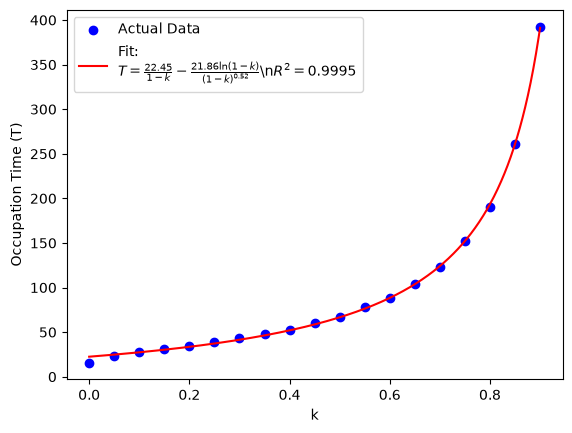

In [17]:

# 1. Define the 3-parameter Logistic Growth Model
def occupation_time(k,D,beta, gamma):
    return D / (1 - k) - beta * np.log(1 - k) / ((1 - k) ** gamma)


# Fit curve
p0 = [10,33, 1.0]
popt, _ = curve_fit(occupation_time, k1, t1, p0=p0)
D_fit, beta_fit, gamma_fit = popt


# --- Calculate Coefficient of Determination (R^2) ---
t1_pred = occupation_time(k1, *popt)
ss_res = np.sum((t1 - t1_pred) ** 2)  # Residual sum of squares
ss_tot = np.sum((t1 - np.mean(t1)) ** 2)  # Total sum of squares
r2 = 1 - (ss_res / ss_tot)  # R^2 score
6
print(f"R^2 score: {r2:.4f}")

# Label including R^2
eq_label = (
    rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}} - "
    rf"\frac{{{float(beta_fit):.2f} \ln(1 - k)}}{{(1 - k)^{{{gamma_fit:.2f}}}}}$"
    rf"\n$R^2 = {r2:.4f}$"
)

k_dense = np.linspace(min(k1), max(k1), 1000)
t_fit = occupation_time(k_dense, *popt)

# Plot
plt.scatter(k1, t1, label="Actual Data", color="blue")
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red")
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.show()

# holding the D_fit parameter to be the time at k=0

R^2 score: 0.9978


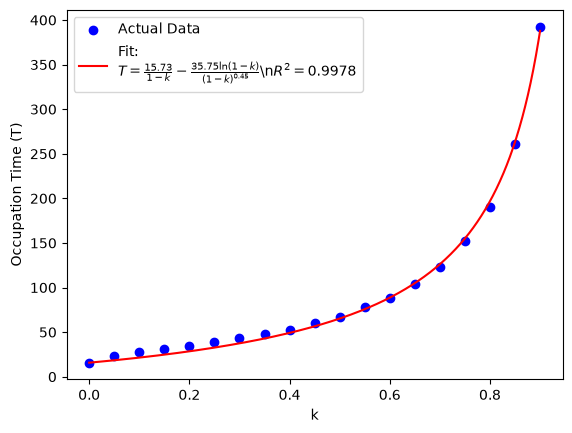

In [ ]:
D = 15.73417052
# 1. Define the 3-parameter Logistic Growth Model
def occupation_time(k,beta, gamma):
    return D / (1 - k) - beta * np.log(1 - k) / ((1 - k) ** gamma)


# Fit curve
p0 = [33, 1.0]
popt, _ = curve_fit(occupation_time, k1, t1, p0=p0)
beta_fit, gamma_fit = popt


# --- Calculate Coefficient of Determination (R^2) ---
t1_pred = occupation_time(k1, *popt)
ss_res = np.sum((t1 - t1_pred) ** 2)  # Residual sum of squares
ss_tot = np.sum((t1 - np.mean(t1)) ** 2)  # Total sum of squares
r2 = 1 - (ss_res / ss_tot)  # R^2 score
6
print(f"R^2 score: {r2:.4f}")

# Label including R^2
eq_label = (
    rf"$T = \frac{{{D:.2f}}}{{1 - k}} - "
    rf"\frac{{{float(beta_fit):.2f} \ln(1 - k)}}{{(1 - k)^{{{gamma_fit:.2f}}}}}$"
    rf"\n$R^2 = {r2:.4f}$"
)

k_dense = np.linspace(min(k1), max(k1), 1000)
t_fit = occupation_time(k_dense, *popt)

# Plot
plt.scatter(k1, t1, label="Actual Data", color="blue")
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red")
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.show()

# Applied with OCTANT ENCLOSURE

In [ ]:
###### from math import log
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

data1 = np.loadtxt("sims=10,k=vary, type=octant_enclosed.dat")
enclosed_k1 = data1[:, 0]
enclosed_t1 = data1[:, 1]
# D_o = data1[0, 1]
beta = 32.24
print(enclosed_t1)
print(enclosed_k1)


[ 28.56684193  34.37271532  46.34052689  52.70667152  67.15321922
  67.15321922  92.05776186  92.05776186 120.57586314 211.23518745
 391.54521732  18.64788453]
[0.1        0.2        0.30000001 0.40000001 0.5        0.5
 0.60000002 0.60000002 0.69999999 0.80000001 0.89999998 0.        ]


R^2 score: 0.9981


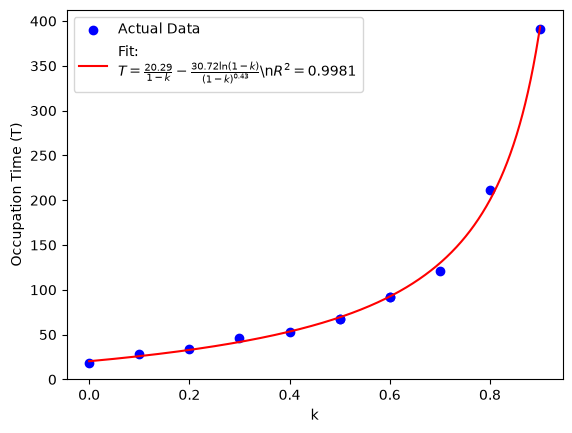

In [47]:

# 1. Define the 3-parameter Logistic Growth Model
def occupation_time(k,D,beta, gamma):
    return D / (1 - k) - beta * np.log(1 - k) / ((1 - k) ** gamma)


# Fit curve
p0 = [10,33, 1.0]
popt, _ = curve_fit(occupation_time, enclosed_k1, enclosed_t1, p0=p0)
D_fit, beta_fit, gamma_fit = popt


# --- Calculate Coefficient of Determination (R^2) ---
t1_pred = occupation_time(k1, *popt)
ss_res = np.sum((t1 - t1_pred) ** 2)  # Residual sum of squares
ss_tot = np.sum((t1 - np.mean(t1)) ** 2)  # Total sum of squares
r2 = 1 - (ss_res / ss_tot)  # R^2 score
6
print(f"R^2 score: {r2:.4f}")

# Label including R^2
eq_label = (
    rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}} - "
    rf"\frac{{{float(beta_fit):.2f} \ln(1 - k)}}{{(1 - k)^{{{gamma_fit:.2f}}}}}$"
    rf"\n$R^2 = {r2:.4f}$"
)

k_dense = np.linspace(min(k1), max(k1), 1000)
t_fit = occupation_time(k_dense, *popt)

# Plot
plt.scatter(enclosed_k1, enclosed_t1, label="Actual Data", color="blue")
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red")
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.show()

# Dropping the 2nd term in the octant algorithm

Fitted D: 38.4311
R^2 score: 0.9862


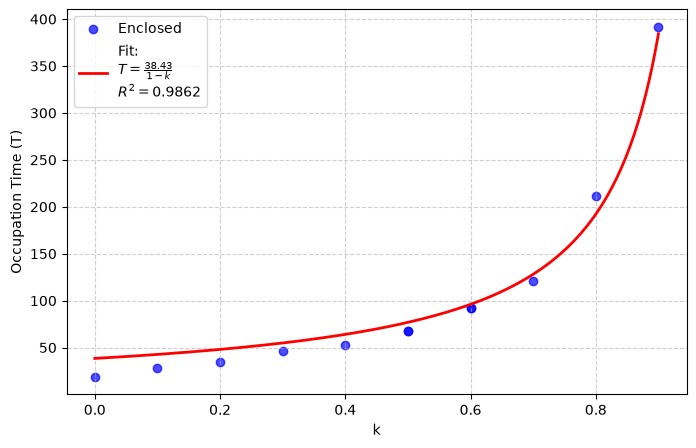

In [ ]:
import numpy as np


In [1]:
print('hello world')

hello world


In [ ]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Model fitting D with beta = 0
def occupation_time(k, D_fit):
    return D_fit / (1.0 - k)

# Fit curve to find optimal D
popt, _ = curve_fit(occupation_time, enclosed_k1, enclosed_t1, p0=[18.0])
D_fit = popt[0]

# Predictions and R^2
t1_pred = occupation_time(enclosed_k1, D_fit)
ss_res = np.sum((enclosed_t1 - t1_pred) ** 2)
ss_tot = np.sum((enclosed_t1 - np.mean(enclosed_t1)) ** 2)
r2 = 1.0 - (ss_res / ss_tot)

print(f"Fitted D: {D_fit:.4f}")
print(f"R^2 score: {r2:.4f}")

# Plotting
k_dense = np.linspace(min(enclosed_k1), max(enclosed_k1), 1000)
t_fit = occupation_time(k_dense, D_fit)

eq_label = rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}}$" + f"\n$R^2 = {r2:.4f}$"

plt.figure(figsize=(8, 5))
plt.scatter(enclosed_k1, enclosed_t1, label="Enclosed", color="blue", alpha=0.7)
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red", linewidth=2)
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# 3D Version. max_range = 0.90, k = vary, sims = 500
I put a maximum range to where planets can reach other planets.


Fitted D: 10.4192
R^2 score: 0.9996


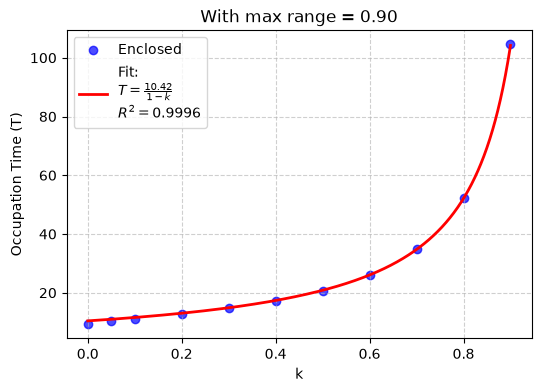

In [6]:
###### from math import log
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

data1 = np.loadtxt("3D_with_enclosure_static,curve,k=vary,sims=500,hb=0.9.dat")
k1 = data1[:, 0]
t1 = data1[:, 1]
t_de = data1[:,2]
t_m = data1[:,3]

# Model fitting D with beta = 0
def occupation_time(k, D_fit):
    return D_fit / (1.0 - k)

# Fit curve to find optimal D
popt, _ = curve_fit(occupation_time, k1, t1, p0=[18.0])
D_fit = popt[0]

# Predictions and R^2
t1_pred = occupation_time(k1, D_fit)
ss_res = np.sum((t1 - t1_pred) ** 2)
ss_tot = np.sum((t1 - np.mean(t1)) ** 2)
r2 = 1.0 - (ss_res / ss_tot)

print(f"Fitted D: {D_fit:.4f}")
print(f"R^2 score: {r2:.4f}")

# Plotting
k_dense = np.linspace(min(k1), max(k1), 1000)
t_fit = occupation_time(k_dense, D_fit)

eq_label = rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}}$" + f"\n$R^2 = {r2:.4f}$"


plt.figure(figsize=(6,4))
plt.scatter(k1, t1, label="Enclosed", color="blue", alpha=0.7)
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red", linewidth=2)
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.title("With max range = 0.90")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()




# Replicating figure 2 in the first paper 
We apply the enclosure mechanism by limiting the range of the planet to max_range = 0.90. We see the trend of n(t) vs t here. 

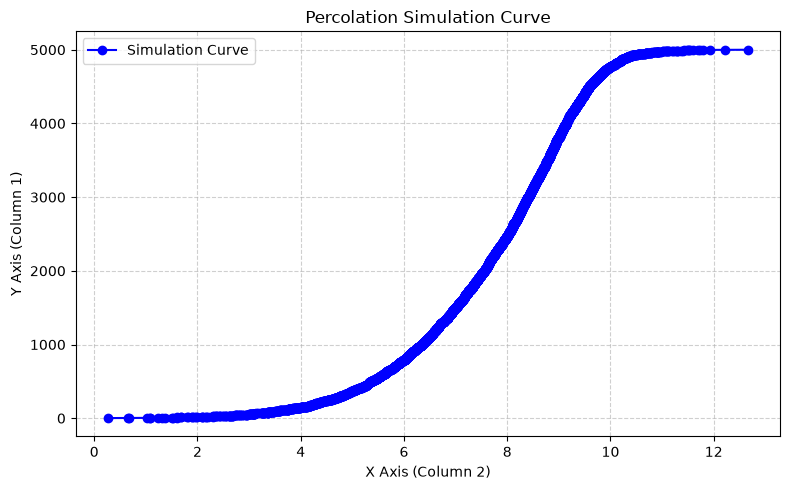

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data file 
# 'sep=r"\s+"' handles files separated by any amount of spaces or tabs
data_path = "n(t)_vs_t,sims=1,k=0.20.dat"

try:
    # Read file assuming no header row exists
    df = pd.read_csv(data_path, sep=r"\s+", header=None)
    
    # 2. Assign axes based on your column mapping
    # Column 0 (1st column) -> Y-axis
    # Column 1 (2nd column) -> X-axis
    y_data = df.iloc[:, 0]
    x_data = df.iloc[:, 1]

    # 3. Create the plot
    plt.figure(figsize=(8, 5))
    plt.plot(x_data, y_data, marker='o', linestyle='-', color='b', label='Simulation Curve')
    
    # 4. Add formatting and metadata
    plt.title("Percolation Simulation Curve")
    plt.xlabel("X Axis (Column 2)")
    plt.ylabel("Y Axis (Column 1)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    # Display the window
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Error: The file '{data_path}' was not found in your directory.")
except Exception as e:
    print(f"An error occurred while parsing the data: {e}")


--- Fit Results ---
N_0 = 6623.1899 ± 11.9659
k   = 0.8951 ± 0.0015
t_0 = 7.3667 ± 0.0045
R²  = 0.9988


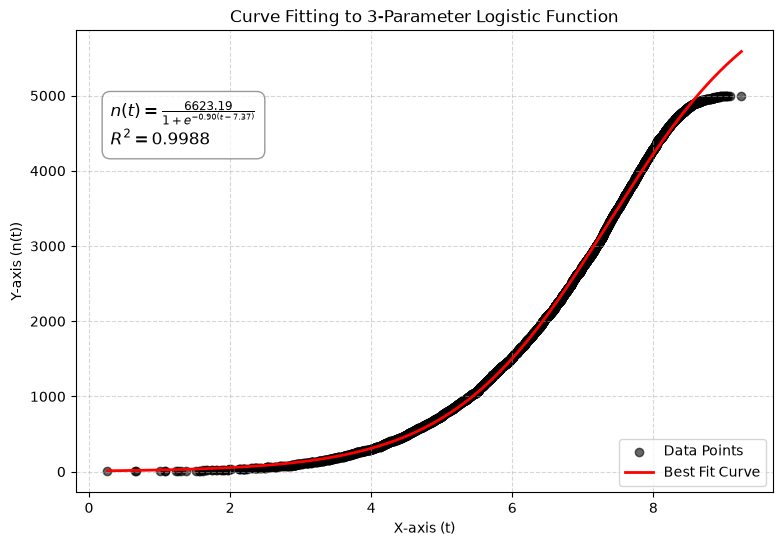

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Define the 3-parameter function
def logistic_model(t, N_0, k, t_0):
    return N_0 / (1 + np.exp(-k * (t - t_0)))

# 2. Load data from the .dat file
data = np.loadtxt("n(t)_vs_t,sims=1,k=0.20,max_range=0.9.dat")

# Extract columns (First column is y-axis, second column is x-axis)
y_data = data[:, 0]
t_data = data[:, 1]  # x-axis represents independent variable 't'

# 3. Provide initial guesses for the parameters [N_0, k, t_0]
initial_guesses = [max(y_data), 1.0, np.median(t_data)]

# 4. Perform the curve fit
popt, pcov = curve_fit(
    logistic_model, t_data, y_data, p0=initial_guesses, maxfev=10000
)

# Extract optimized parameters
N_0_opt, k_opt, t_0_opt = popt
perr = np.sqrt(np.diag(pcov))  # Standard deviations of the parameters

# 5. Calculate R^2 (Coefficient of Determination)
y_pred = logistic_model(t_data, *popt)
ss_res = np.sum((y_data - y_pred) ** 2)
ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

# 6. Print out the results including R^2
print("--- Fit Results ---")
print(f"N_0 = {N_0_opt:.4f} ± {perr[0]:.4f}")
print(f"k   = {k_opt:.4f} ± {perr[1]:.4f}")
print(f"t_0 = {t_0_opt:.4f} ± {perr[2]:.4f}")
print(f"R²  = {r_squared:.4f}")

# 7. Generate smooth curves for plotting the fit
t_fit = np.linspace(min(t_data), max(t_data), 500)
y_fit = logistic_model(t_fit, *popt)

# 8. Plot the raw data and the fitted function
plt.figure(figsize=(9, 6))
plt.scatter(t_data, y_data, color="black", label="Data Points", alpha=0.6)
plt.plot(t_fit, y_fit, color="red", linewidth=2, label="Best Fit Curve")

# --- NEW: 9. Display the specific fitted equation directly on the screen ---
# Constructing a clean LaTeX string using your numerical results
equation_text = (
    f"$n(t) = \\frac{{{N_0_opt:.2f}}}{{1 + e^{{-{k_opt:.2f}(t - {t_0_opt:.2f})}}}}$\n"
    f"$R^2 = {r_squared:.4f}$"
)

# Place the text box on the plot. 
# transform=plt.gca().transAxes anchors coordinates to the axis frame (0 to 1) 
# so it stays safely in the upper-left quadrant regardless of your raw data scale.
plt.text(
    0.05, 0.85, 
    equation_text, 
    transform=plt.gca().transAxes, 
    fontsize=12, 
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.8)
)

# Formatting the plot
plt.xlabel("X-axis (t)")
plt.ylabel("Y-axis (n(t))")
plt.title("Curve Fitting to 3-Parameter Logistic Function")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)

# Show the plot
plt.show()


File 1: n(t)_vs_t,sims=1,k=0.50,max_range=0.9.dat
  n(t) = 5364.39 / (1 + e^(-0.5351 * (t - 12.34)))
  R²   = 0.9979

File 2: n(t)_vs_t,sims=1,k=0.50,max_range=2.5.dat
  n(t) = 4923.55 / (1 + e^(-0.5584 * (t - 11.87)))
  R²   = 0.9989

Could not process file 'n(t)_vs_t,sims=1,k=0.50,max_range=5.0.dat': array must not contain infs or NaNs
Could not process file 'n(t)_vs_t,sims=1,k=0.50,max_range=7.5.dat': array must not contain infs or NaNs
Could not process file 'n(t)_vs_t,sims=1,k=0.50,max_range=10.0.dat': array must not contain infs or NaNs


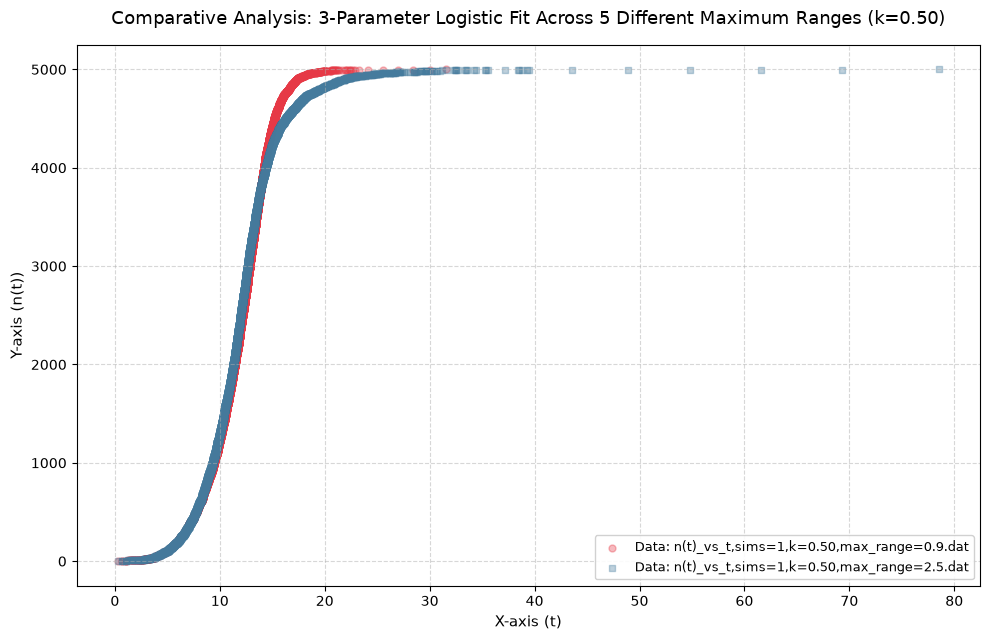

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Define the 3-parameter function
def logistic_model(t, N_0, k, t_0):
    return N_0 / (1 + np.exp(-k * (t - t_0)))

# 2. Define the 5 files you want to compare
file_list = [
    "n(t)_vs_t,sims=1,k=0.50,max_range=0.9.dat",
    "n(t)_vs_t,sims=1,k=0.50,max_range=2.5.dat",
    "n(t)_vs_t,sims=1,k=0.50,max_range=5.0.dat",
    "n(t)_vs_t,sims=1,k=0.50,max_range=7.5.dat",
    "n(t)_vs_t,sims=1,k=0.50,max_range=10.0.dat"
]

# Set up 5 distinct visual styles (Colors and Markers)
colors = ["#E63946", "#457B9D", "#2A9D8F", "#F4A261", "#8338EC"]
markers = ["o", "s", "^", "D", "v"]

# Adjusted figure layout (removed the right margin compression)
fig, ax = plt.subplots(figsize=(10, 6.5))

# 3. Loop over each file to extract, fit, and plot data
for i, filename in enumerate(file_list):
    try:
        # Load dataset
        data = np.loadtxt(filename)
        y_data = data[:, 0]
        t_data = data[:, 2]
        
        # Determine unique initial guesses for this specific file
        initial_guesses = [max(y_data), 1.0, np.median(t_data)]
        
        # Execute curve fitting
        popt, pcov = curve_fit(
            logistic_model, t_data, y_data, p0=initial_guesses, maxfev=10000
        )
        
        # Calculate R^2 score
        y_pred = logistic_model(t_data, *popt)
        ss_res = np.sum((y_data - y_pred) ** 2)
        ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        
        # Clean up filename string for the legend label
        display_name = filename.split('/')[-1]
        
        # --- NEW: Print the best fit curve equation directly to the terminal ---
        print(f"File {i+1}: {display_name}")
        print(f"  n(t) = {popt[0]:.2f} / (1 + e^(-{popt[1]:.4f} * (t - {popt[2]:.2f})))")
        print(f"  R²   = {r_squared:.4f}\n")
        
        # Plot raw scatter points
        ax.scatter(
            t_data, y_data, 
            color=colors[i], marker=markers[i], alpha=0.35, s=25,
            label=f"Data: {display_name}"
        )
        
        # Generate and plot the smooth curve fit line
        t_fit = np.linspace(min(t_data), max(t_data), 500)
        y_fit = logistic_model(t_fit, *popt)
        # ax.plot(
        #     t_fit, y_fit, 
        #     color=colors[i], linewidth=2.5, 
        #     label=f"Fit {i+1} ($R^2 = {r_squared:.3f}$)"
        # )
        
    except Exception as e:
        print(f"Could not process file '{filename}': {e}")

# 4. Final plot cosmetic styling
ax.set_xlabel("X-axis (t)", fontsize=11)
ax.set_ylabel("Y-axis (n(t))", fontsize=11)
ax.set_title("Comparative Analysis: 3-Parameter Logistic Fit Across 5 Different Maximum Ranges (k=0.50)", fontsize=13, pad=15)

# Placed the standard legend in the lower right corner inside the plot field
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.5)

# Render output
plt.tight_layout()
plt.show()


File 1: n(t)_vs_t,sims=1,k=0.20,max_range=0.9.dat
  n(t) = 6425.96 / (1 + e^(-0.7924 * (t - 7.89)))
  R² = 0.9989

File 2: n(t)_vs_t,sims=1,k=0.20,max_range=2.5.dat
  n(t) = 5567.39 / (1 + e^(-0.8416 * (t - 7.64)))
  R² = 0.9990

File 3: n(t)_vs_t,sims=1,k=0.20,max_range=5.0.dat
  n(t) = 4985.86 / (1 + e^(-0.8849 * (t - 7.40)))
  R² = 0.9990

File 4: n(t)_vs_t,sims=1,k=0.20,max_range=7.5.dat
  n(t) = 4912.49 / (1 + e^(-0.8936 * (t - 7.37)))
  R² = 0.9988

File 5: n(t)_vs_t,sims=1,k=0.20,max_range=10.0.dat
  n(t) = 4904.59 / (1 + e^(-0.8945 * (t - 7.36)))
  R² = 0.9988



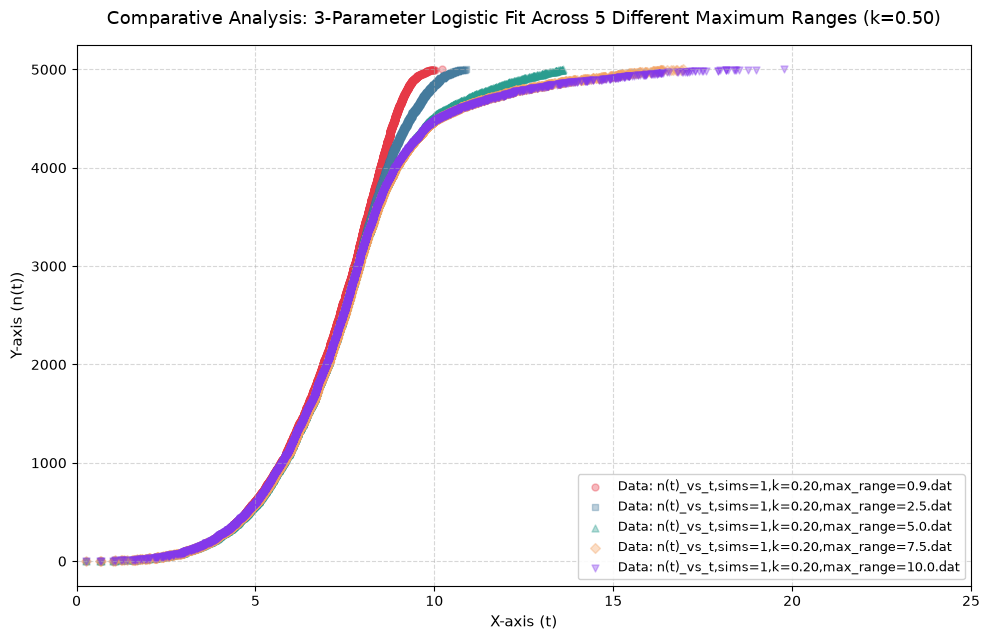

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Define the 3-parameter function
def logistic_model(t, N_0, k, t_0):
    return N_0 / (1 + np.exp(-k * (t - t_0)))

# 2. Define the 5 files you want to compare
file_list = [
    "n(t)_vs_t,sims=1,k=0.20,max_range=0.9.dat",
    "n(t)_vs_t,sims=1,k=0.20,max_range=2.5.dat",
    "n(t)_vs_t,sims=1,k=0.20,max_range=5.0.dat",
    "n(t)_vs_t,sims=1,k=0.20,max_range=7.5.dat",
    "n(t)_vs_t,sims=1,k=0.20,max_range=10.0.dat"
]

# Set up 5 distinct visual styles (Colors and Markers)
colors = ["#E63946", "#457B9D", "#2A9D8F", "#F4A261", "#8338EC"]
markers = ["o", "s", "^", "D", "v"]

# Adjusted figure layout (removed the right margin compression)
fig, ax = plt.subplots(figsize=(10, 6.5))

# 3. Loop over each file to extract, fit, and plot data
for i, filename in enumerate(file_list):
    try:
        # Load dataset
        data = np.loadtxt(filename)
        
        # Filter out rows containing NaN values
        valid_mask = ~np.isnan(data).any(axis=1)
        data = data[valid_mask]
        
        y_data = data[:, 0]
        t_data = data[:, 2]

        # Ensure we still have data points left after filtering
        if len(t_data) == 0:
            print(f"File {i+1}: {filename} has no valid data after removing NaNs.")
            continue

        # Determine unique initial guesses for this specific file
        initial_guesses = [max(y_data), 1.0, np.median(t_data)]

        # Execute curve fitting
        popt, pcov = curve_fit(
            logistic_model, t_data, y_data, p0=initial_guesses, maxfev=10000
        )

        # Calculate R^2 score
        y_pred = logistic_model(t_data, *popt)
        ss_res = np.sum((y_data - y_pred) ** 2)
        ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)

        # Clean up filename string for the legend label
        display_name = filename.split('/')[-1]

        # Print the best fit curve equation directly to the terminal
        print(f"File {i+1}: {display_name}")
        print(f"  n(t) = {popt[0]:.2f} / (1 + e^(-{popt[1]:.4f} * (t - {popt[2]:.2f})))")
        print(f"  R² = {r_squared:.4f}\n")

        # Plot raw scatter points
        ax.scatter(
            t_data, y_data, color=colors[i], marker=markers[i], alpha=0.35, s=25,
            label=f"Data: {display_name}"
        )

        # Generate and plot the smooth curve fit line
        t_fit = np.linspace(min(t_data), max(t_data), 500)
        y_fit = logistic_model(t_fit, *popt)
        # ax.plot(
        #     t_fit, y_fit,
        #     color=colors[i], linewidth=2.5,
        #     label=f"Fit {i+1} ($R^2 = {r_squared:.3f}$)"
        # )
        
    except Exception as e:
        print(f"Could not process file '{filename}': {e}")

# 4. Final plot cosmetic styling
ax.set_xlabel("X-axis (t)", fontsize=11)
ax.set_ylabel("Y-axis (n(t))", fontsize=11)
ax.set_title("Comparative Analysis: 3-Parameter Logistic Fit Across 5 Different Maximum Ranges (k=0.50)", fontsize=13, pad=15)

# --- NEW: Set explicit Y-axis limits ---
# Adjust these values depending on your expected n(t) ceiling
ax.set_xlim(0, 25)

# Placed the standard legend in the lower right corner inside the plot field
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.5)

# Render output
plt.tight_layout()
plt.show()


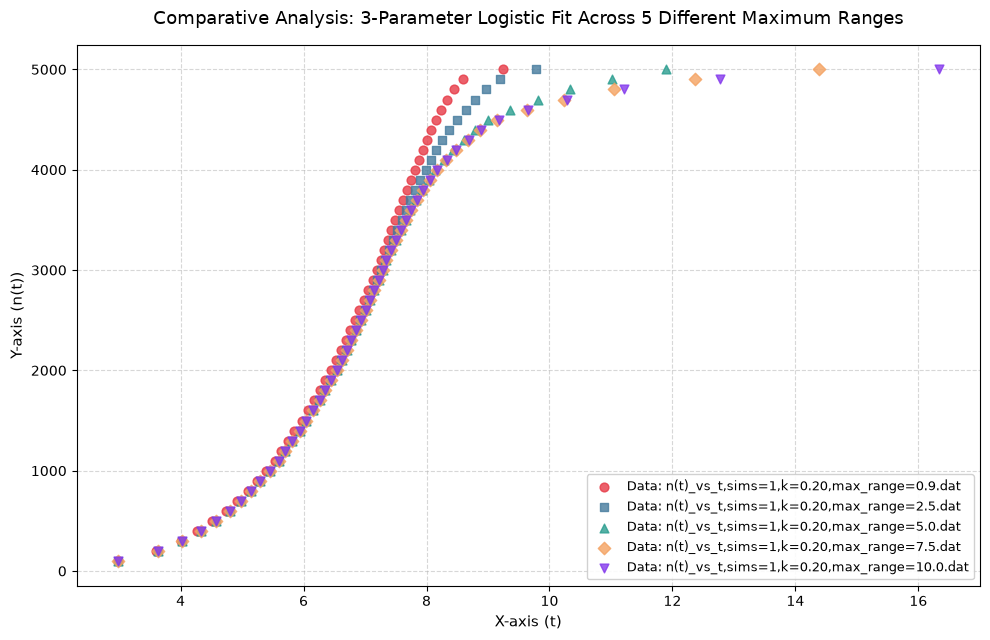

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Define the 3-parameter function
def logistic_model(t, N_0, k, t_0):
    return N_0 / (1 + np.exp(-k * (t - t_0)))

# 2. Define the 5 files you want to compare
file_list = [
    "n(t)_vs_t,sims=1,k=0.20,max_range=0.9.dat",
    "n(t)_vs_t,sims=1,k=0.20,max_range=2.5.dat",
    "n(t)_vs_t,sims=1,k=0.20,max_range=5.0.dat",
    "n(t)_vs_t,sims=1,k=0.20,max_range=7.5.dat",
    "n(t)_vs_t,sims=1,k=0.20,max_range=10.0.dat"
]

colors = ["#E63946", "#457B9D", "#2A9D8F", "#F4A261", "#8338EC"]
markers = ["o", "s", "^", "D", "v"]

fig, ax = plt.subplots(figsize=(10, 6.5))

# 3. Loop over each file to extract, fit, and plot data
for i, filename in enumerate(file_list):
    try:
        data = np.loadtxt(filename)
        y_data = data[:, 0]
        t_data = data[:, 1]
        
        # Curve fitting
        initial_guesses = [max(y_data), 1.0, np.median(t_data)]
        popt, pcov = curve_fit(logistic_model, t_data, y_data, p0=initial_guesses, maxfev=10000)
        
        # Calculate R^2
        y_pred = logistic_model(t_data, *popt)
        ss_res = np.sum((y_data - y_pred) ** 2)
        ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        
        display_name = filename.split('/')[-1]
        
        # --- NEW: Filter for values perfectly divisible by 100 ---
        # 1. Round to closest integer to handle float precision safely
        y_round = np.round(y_data).astype(int)
        
        # 2. Find indices where the rounded value is a multiple of 100
        divisible_by_100_idx = np.where(y_round % 100 == 0)[0]
        
        # 3. Keep only the first occurrence of each milestone to prevent plateau crowding
        clean_t = []
        clean_y = []
        seen_milestones = set()
        
        for idx in divisible_by_100_idx:
            milestone = y_round[idx]
            if milestone not in seen_milestones:
                seen_milestones.add(milestone)
                clean_t.append(t_data[idx])
                clean_y.append(y_data[idx]) # use original unrounded data point
        
        # Plot cleaned, spaced-out scatter points
        ax.scatter(
            clean_t, clean_y, 
            color=colors[i], marker=markers[i], alpha=0.8, s=40, zorder=3,
            label=f"Data: {display_name}"
        )
        
        # Generate and plot the smooth curve fit line
        t_fit = np.linspace(min(t_data), max(t_data), 500)
        y_fit = logistic_model(t_fit, *popt)
        # ax.plot(
        #     t_fit, y_fit, 
        #     color=colors[i], linewidth=2, zorder=2,
        #     label=f"Fit {i+1} ($R^2 = {r_squared:.3f}$)"
        # )
        
    except Exception as e:
        print(f"Could not process file '{filename}': {e}")

# 4. Final plot cosmetic styling
ax.set_xlabel("X-axis (t)", fontsize=11)
ax.set_ylabel("Y-axis (n(t))", fontsize=11)
ax.set_title("Comparative Analysis: 3-Parameter Logistic Fit Across 5 Different Maximum Ranges", fontsize=13, pad=15)

ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the 3 data files to import
# Replace these strings with your actual filenames
file_list = [
    "n(t)_vs_t,dark_energy,max_range=10.0,sims=1,H=0.02.dat",
    "n(t)_vs_t,dark_energy,max_range=10.0,sims=1,H=0.04.dat",
    "n(t)_vs_t,dark_energy,max_range=10.0,sims=1,H=0.06.dat"
]

# Set up distinct visual styles for the 3 datasets
colors = ["#E63946", "#457B9D", "#2A9D8F"]  # Red, Blue, Teal
markers = ["o", "s", "^"]                    # Circle, Square, Triangle

# Initialize the plot window
plt.figure(figsize=(10, 6.5))

# 2. Loop over each file to extract and plot data
for i, filename in enumerate(file_list):
    try:
        # Load dataset (handles space/tab delimited text files automatically)
        data = np.loadtxt(filename)
        
        # Extract columns:
        # data[:, 0] targets the 1st column (Y-axis)
        # data[:, 2] targets the 3rd column (X-axis)
        y_data = data[:, 0]
        x_data = data[:, 2]
        
        # Clean up filename path string for the legend label
        display_name = filename.split('/')[-1]
        
        # Generate the scatter plot for this file
        plt.scatter(
            x_data, y_data, 
            color=colors[i], 
            marker=markers[i], 
            alpha=0.6, 
            s=30,
            label=f"Dataset {i+1}: {display_name}"
        )
        
    except Exception as e:
        print(f"Could not process file '{filename}': {e}")

# 3. Final plot cosmetic styling
plt.xlabel("X-axis (Column 3)", fontsize=11)
plt.ylabel("Y-axis (Column 1)", fontsize=11)
plt.title("max_range=10.0, H=vary", fontsize=13, pad=15)
plt.legend(loc="best", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)

# Render output window
plt.tight_layout()
plt.show()


: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the 5 data files to import
file_list = [
    "n(t)_vs_t,dark_energy,max_range=0.9,sims=1,H=0.02.dat",
    "n(t)_vs_t,dark_energy,max_range=0.9,sims=1,H=0.04.dat",
    "n(t)_vs_t,dark_energy,max_range=0.9,sims=1,H=0.06.dat",
    "n(t)_vs_t,dark_energy,max_range=0.9,sims=1,H=0.08.dat",
    "n(t)_vs_t,dark_energy,max_range=0.9,sims=1,H=0.10.dat"
]

# Set up distinct visual styles for the 5 datasets
colors = ["#E63946", "#457B9D", "#2A9D8F", "#F4A261", "#E76F51"]  # Red, Blue, Teal, Orange, Coral
markers = ["o", "s", "^", "D", "v"]                     # Circle, Square, Triangle, Diamond, Inverted Triangle

# Initialize the plot window
plt.figure(figsize=(10, 6.5))

# 2. Loop over each file to extract and plot data
for i, filename in enumerate(file_list):
    try:
        # Load dataset (handles space/tab delimited text files automatically)
        data = np.loadtxt(filename)
        
        # Extract columns:
        # data[:, 0] targets the 1st column (Y-axis)
        # data[:, 2] targets the 3rd column (X-axis)
        y_data = data[:, 0]
        x_data = data[:, 2]
        
        # Clean up filename path string for the legend label
        display_name = filename.split('/')[-1]
        
        # Generate the scatter plot for this file
        plt.scatter(
            x_data, y_data, 
            color=colors[i], 
            marker=markers[i], 
            alpha=0.6, 
            s=30,
            label=f"Dataset {i+1}: {display_name}"
        )
        
    except Exception as e:
        print(f"Could not process file '{filename}': {e}")

# 3. Final plot cosmetic styling
plt.xlabel("X-axis (Column 3)", fontsize=11)
plt.ylabel("Y-axis (Column 1)", fontsize=11)
plt.title("Scatter Plot Comparison of 5 Datasets", fontsize=13, pad=15)
plt.legend(loc="best", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)

# Render output window
plt.tight_layout()
plt.show()